In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re

In [2]:
# samples already merged, import dataset as anndata object

dir = "PBMC_datasets/3/merged_10x/"

adata = sc.read_10x_mtx(
    dir,
    var_names="gene_symbols",
    cache=False
)
adata.var_names_make_unique()

In [3]:
print(adata)

AnnData object with n_obs × n_vars = 128903 × 15776
    var: 'gene_ids'


In [4]:
display(adata.obs.head())
display(adata.var.head()) 

""
N1-AAAGATGAGCTAACAA
N1-AACCATGTCATGTCCC
N1-ACCGTAACACATGACT
N1-AGATCTGAGTGAATTG
N1-AGGTCATCACGTAAGG


,gene_ids
TSPAN6,TSPAN6
DPM1,DPM1
SCYL3,SCYL3
C1orf112,C1orf112
FGR,FGR


In [5]:
pd.DataFrame(
    adata.X[:10, :20].toarray(),
    index=adata.obs_names[:10],
    columns=adata.var_names[:20]
)

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,LAS1L,ENPP4,ANKIB1,CYP51A1,KRIT1,RAD52,BAD,LAP3,CD99
N1-AAAGATGAGCTAACAA,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
N1-AACCATGTCATGTCCC,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
N1-ACCGTAACACATGACT,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
N1-AGATCTGAGTGAATTG,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
N1-AGGTCATCACGTAAGG,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
N1-ATAGACCAGCGTTTAC,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
N1-ATCATCTAGCTGGAAC,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
N1-CACAGTACACCTATCC,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
N1-CACATAGTCGCACTCT,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
N1-CATGCCTCATACTACG,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0


In [6]:
# add (already given) metadata

metadata = pd.read_csv("PBMC_datasets/3/metadata.txt", sep = "\t")
metadata = metadata.set_index("cell")

metadata.head()

,sample,sampleType,clusterID,clusterAnno,cellType,cellType2,clonotype,alpha_CDR3_aa,beta_CDR3_aa
cell,,,,,,,,,
N1-AAAGATGAGCTAACAA,N1,Control(Blood),C8,C8: Naive CD8+ T cells,CD8,Naive CD8+ T cells,clonotype13285,CGTSTWAGTASKLTF,CASSATGYSNQPQHF
N1-AACCATGTCATGTCCC,N1,Control(Blood),C3,C3: Naive CD4+ T cells,CD4,Naive CD4+ T cells,clonotype31787,CAVTWGTYKYIF,CASSKDRGDYGYTF
N1-ACCGTAACACATGACT,N1,Control(Blood),C12,C12: Naive CD4+ T cells,CD4,Naive CD4+ T cells,clonotype27665,CAVSYSGNTGKLIF,CASRERPQVTLVAFF
N1-AGATCTGAGTGAATTG,N1,Control(Blood),C8,C8: Naive CD8+ T cells,CD8,Naive CD8+ T cells,clonotype86747,NaN,CASSQDATGGMNTEAFF
N1-AGGTCATCACGTAAGG,N1,Control(Blood),C12,C12: Naive CD4+ T cells,CD4,Naive CD4+ T cells,clonotype51826,CATDALSGGSYIPTF,CASSSPQETQYF


In [7]:
# merge metadata with adata.obs

adata.obs = adata.obs.join(metadata, how="left") # align to adata cells (keeps adata order)


In [8]:
# filter for only Control(Blood) and Parkinson(Blood) samples

adata = adata[adata.obs["sampleType"].isin(["Control(Blood)", "Parkinson(Blood)"])]
print(adata)

# check how many participants of each type (control vs parkinsons) we have

adata.obs.groupby("sampleType")["sample"].nunique()

View of AnnData object with n_obs × n_vars = 108775 × 15776
    obs: 'sample', 'sampleType', 'clusterID', 'clusterAnno', 'cellType', 'cellType2', 'clonotype', 'alpha_CDR3_aa', 'beta_CDR3_aa'
    var: 'gene_ids'


sampleType
Control(Blood)      13
Parkinson(Blood)     8
Name: sample, dtype: int64

In [9]:
# change sampleType/diagnosis name (consistency with other datasets)

adata.obs["sampleType"] = adata.obs["sampleType"].map({"Control(Blood)": "CTRL", "Parkinson(Blood)": "PD"})
adata.obs = adata.obs.rename(columns={"sampleType": "diagnosis"})

/var/tmp/pbs.1821454.pbs-7/ipykernel_617641/3579791974.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sampleType"] = adata.obs["sampleType"].map({"Control(Blood)": "CTRL", "Parkinson(Blood)": "PD"})


In [10]:
# add in some missing sample-level metadata (demographics)

sample_meta = pd.DataFrame({
    "sample": ["N1","N2","N3","N4","N5","N6","N7","N8","N9","N10","N11","N12","N13","P1","P2","P3","P4","P5","P6","P7","P8"],
    "age" : [71, 54, 65, 51, 65, 65, "NA", "NA", "NA", "NA", "NA", "NA", "NA", 56, 63, 68, 61, 69, 65, 68, 50],
    "gender": ["F", "F", "F", "M", "M", "M", "NA", "NA", "NA", "NA", "NA", "NA", "NA", "F", "F", "F", "F", "M", "M", "M", "M"]
}).set_index("sample")

adata.obs = adata.obs.join(sample_meta, on="sample", how="left")

# convert "NA" to actual NA values
adata.obs["age"] = pd.to_numeric(adata.obs["age"], errors="coerce").astype("Int64")
adata.obs["gender"] = adata.obs["gender"].replace("NA", pd.NA)

adata.obs.head()

,sample,diagnosis,clusterID,clusterAnno,cellType,cellType2,clonotype,alpha_CDR3_aa,beta_CDR3_aa,age,gender
N1-AAAGATGAGCTAACAA,N1,CTRL,C8,C8: Naive CD8+ T cells,CD8,Naive CD8+ T cells,clonotype13285,CGTSTWAGTASKLTF,CASSATGYSNQPQHF,71,F
N1-AACCATGTCATGTCCC,N1,CTRL,C3,C3: Naive CD4+ T cells,CD4,Naive CD4+ T cells,clonotype31787,CAVTWGTYKYIF,CASSKDRGDYGYTF,71,F
N1-ACCGTAACACATGACT,N1,CTRL,C12,C12: Naive CD4+ T cells,CD4,Naive CD4+ T cells,clonotype27665,CAVSYSGNTGKLIF,CASRERPQVTLVAFF,71,F
N1-AGATCTGAGTGAATTG,N1,CTRL,C8,C8: Naive CD8+ T cells,CD8,Naive CD8+ T cells,clonotype86747,NaN,CASSQDATGGMNTEAFF,71,F
N1-AGGTCATCACGTAAGG,N1,CTRL,C12,C12: Naive CD4+ T cells,CD4,Naive CD4+ T cells,clonotype51826,CATDALSGGSYIPTF,CASSSPQETQYF,71,F


In [11]:
# Run QC globally

# Annotate mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")  

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"], 
    percent_top=[20],
    log1p=True,
    inplace=True
)

adata # to check new metadata cols

AnnData object with n_obs × n_vars = 108775 × 15776
    obs: 'sample', 'diagnosis', 'clusterID', 'clusterAnno', 'cellType', 'cellType2', 'clonotype', 'alpha_CDR3_aa', 'beta_CDR3_aa', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

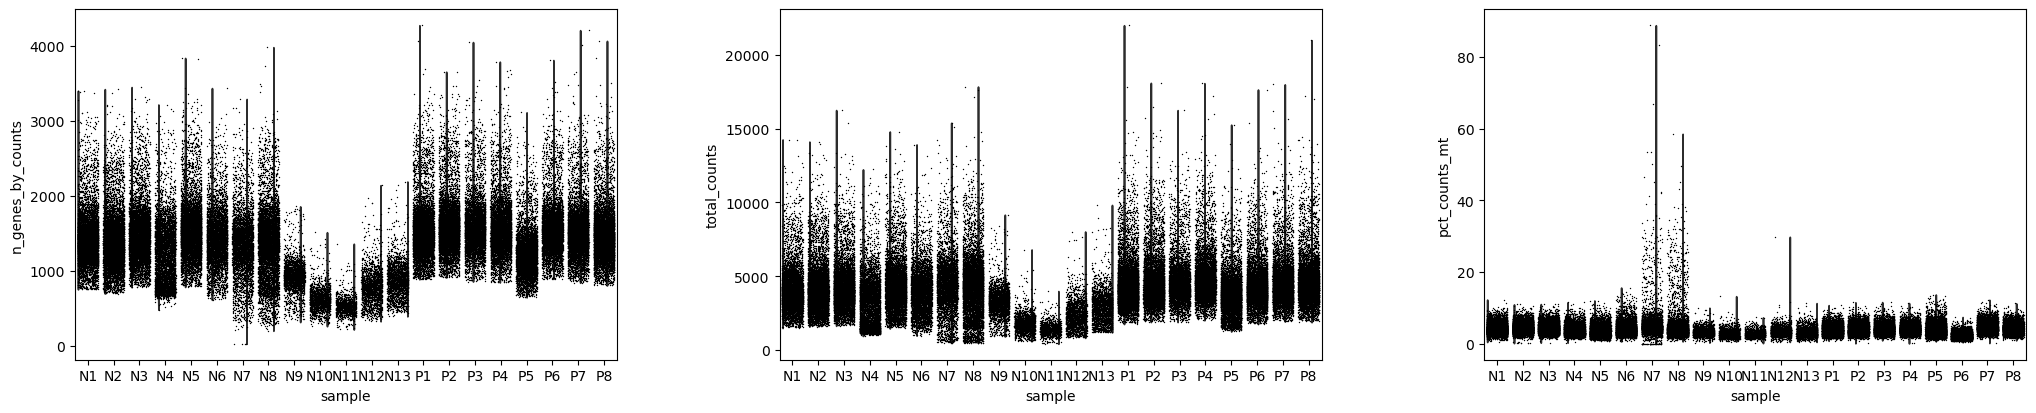

In [12]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="sample",
    jitter=0.4,
    multi_panel=True
)
# does this look normal? no 0 to ~900 n_genes_by counts for some samples?

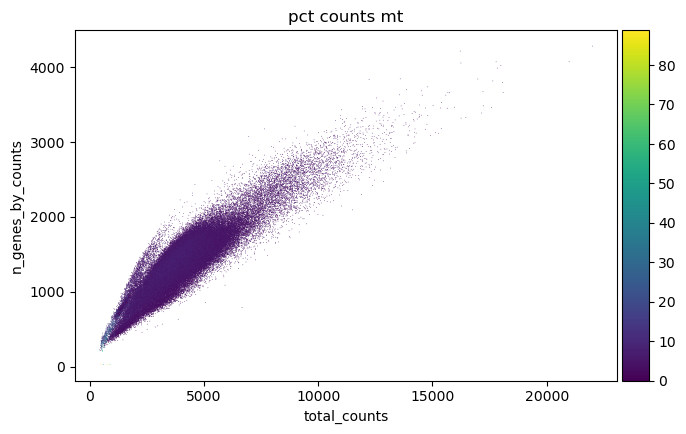

In [13]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [14]:
# group by sample (to avoid skewing from bad samples) and flag outliers based on median absolute deviation (MAD).
def is_outlier_per_sample(adata, metric: str, nmads: int):
    outlier = pd.Series(False, index=adata.obs_names)
    
    for sample, group in adata.obs.groupby("sample"):
        M = group[metric]
        is_out = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
            np.median(M) + nmads * median_abs_deviation(M) < M
        )
        outlier[is_out.index] = is_out
    
    return outlier


In [15]:
adata.obs["outlier"] = (
    is_outlier_per_sample(adata, "log1p_total_counts", 5) # log values easier to visalise and compare (raw total_counts can vary hugely across cells)
    | is_outlier_per_sample(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier_per_sample(adata, "pct_counts_in_top_20_genes", 5) # gives what percentage of total counts comes from the top 20 most highly expressed genes, cells with very high values here are likely to be low quality cells where a few genes dominate the expression profile, which can be a sign of cell stress or damage
)
adata.obs.outlier.value_counts()

outlier
False    106146
True       2629
Name: count, dtype: int64

In [16]:
adata.obs["mt_outlier"] = is_outlier_per_sample(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    101377
True       7398
Name: count, dtype: int64

In [17]:
# filter out low quality cells, check how many cells before and after filtering, and save per sample for later dataframe
cells_before = adata.n_obs
cells_per_sample_before = adata.obs.groupby('sample').size().rename("cells_before_qc")
n_samples = adata.obs["sample"].nunique()

print(f"Total number of cells before filtering of low quality cells: {cells_before}")
# print(f"Number of cells per sample before filtering:\n{cells_per_sample_before}")

adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
cells_per_sample_after_filtering = adata.obs.groupby("sample").size().rename("cells_after_lowq_qc")

print(f"Total number of cells after filtering of low quality cells: {adata.n_obs}")
# print(f"Number of cells per sample after filtering:\n{cells_per_sample_after_filtering}") #intermediate measure just to see (maybe remove), final dataframe will only have final before/after numbers

Total number of cells before filtering of low quality cells: 108775
Total number of cells after filtering of low quality cells: 99412


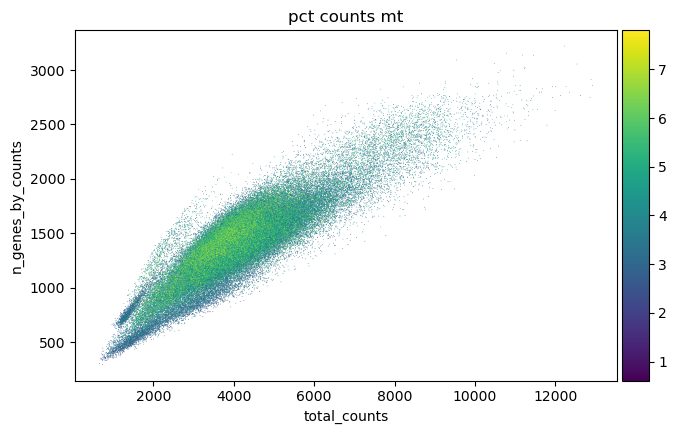

In [18]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [19]:
# Filter out genes not detected in at least 20 cells (not informative)

print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 15776
Number of genes after cell filter: 15220


In [20]:
# doublet detection

sc.pp.scrublet(adata, batch_key="sample")

In [21]:
# inspect new metadata cols and number of predicted doublets 
display(adata.obs[['doublet_score','predicted_doublet']])
adata.obs['predicted_doublet'].value_counts()

,doublet_score,predicted_doublet
N1-AAAGATGAGCTAACAA,0.074675,False
N1-AACCATGTCATGTCCC,0.088561,False
N1-ACCGTAACACATGACT,0.092646,False
N1-AGATCTGAGTGAATTG,0.028219,False
N1-AGGTCATCACGTAAGG,0.101747,False
...,...,...
N13-TTTGCGCGTTGTACAC,0.022059,False
N13-TTTGCGCTCAAAGTAG,0.080645,False
N13-TTTGGTTAGTCAAGGC,0.074581,False
N13-TTTGTCACATTCTCAT,0.055901,False


predicted_doublet
False    99019
True       393
Name: count, dtype: int64

In [22]:
# per sample predicted doublets
doublets_predicted = (adata.obs.groupby("sample")["predicted_doublet"].sum().astype(int).rename("doublets_predicted"))
doublets_predicted

sample
N1       0
N10     11
N11      9
N12     11
N13     12
N2       0
N3       1
N4       4
N5       1
N6       0
N7       2
N8       0
N9      16
P1       1
P2     232
P3       2
P4       0
P5       1
P6      87
P7       0
P8       3
Name: doublets_predicted, dtype: int64

In [23]:
# Filter out doublets

adata = adata[~adata.obs['predicted_doublet']].copy() 

In [24]:
# Save dataset at this tage

ad.settings.allow_write_nullable_strings = True
adata.write("PBMC_datasets/3/QC_rawcounts.h5ad")

In [25]:
# create and export summary table of number of samples/cells per sample before and after filtering

cells_per_sample_after = adata.obs.groupby("sample").size().rename("cells_after_qc")
total_cells_after = adata.n_obs

summary_table = pd.concat(
    [
    cells_per_sample_before, 
    # doublets_predicted,
    cells_per_sample_after
    ],
    axis=1
).astype(int)

# derive removal columns
summary_table["removed_cells"] = (summary_table["cells_before_qc"] - summary_table["cells_after_qc"])
summary_table["pct_removed"] = (
    100 * summary_table["removed_cells"] / summary_table["cells_before_qc"]
).round(2)

summary_table = summary_table.reset_index()  # makes "sample" a normal column

# add diagnosis 
diag_map = adata.obs[["sample", "diagnosis"]].drop_duplicates()
summary_table = summary_table.merge(diag_map, on="sample", how="left")

total_row = pd.DataFrame([{
    "sample": "TOTAL",
    "cells_before_qc": summary_table["cells_before_qc"].sum(),
    # "doublets_predicted": summary_table["doublets_predicted"].sum(),
    "cells_after_qc": summary_table["cells_after_qc"].sum(),
    "removed_cells": summary_table["removed_cells"].sum(),
    "pct_removed": round(
        100 * summary_table["removed_cells"].sum() / summary_table["cells_before_qc"].sum(), 2
    )
}])

summary_table = pd.concat([summary_table, total_row], axis=0, ignore_index=True)

#reorder columns
summary_table = summary_table[
    ["sample", "diagnosis", "cells_before_qc", "cells_after_qc", "removed_cells", "pct_removed"]
]

summary_table.to_csv("/rds/general/user/ztb25/home/PBMC_datasets/3/QC_summary_table.csv", index=False)
summary_table # fix column names maybe

,sample,diagnosis,cells_before_qc,cells_after_qc,removed_cells,pct_removed
0,N1,CTRL,6991,6423,568,8.12
1,N2,CTRL,8019,7433,586,7.31
2,N3,CTRL,7364,6840,524,7.12
3,N4,CTRL,4943,4554,389,7.87
4,N5,CTRL,6765,6152,613,9.06
5,N6,CTRL,4481,3965,516,11.52
6,N7,CTRL,4168,3614,554,13.29
7,N8,CTRL,6741,5999,742,11.01
8,N9,CTRL,2224,1926,298,13.40
9,N10,CTRL,1585,1401,184,11.61


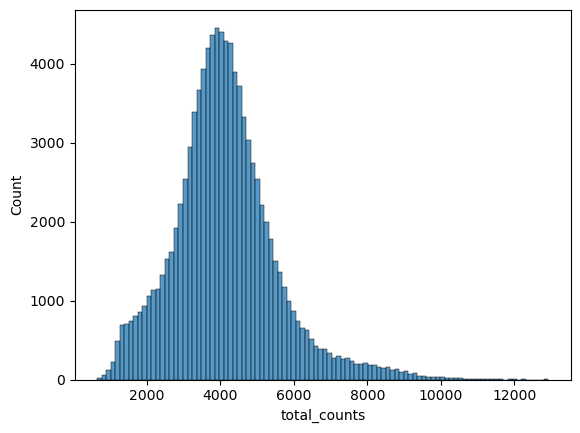

In [26]:
##### Normalisation ##### ----------------------------------------------------------------------------------------------------

# inspect distribution of the raw counts
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

In [27]:
# Method 1: Shifted logarithm (sc-best practice)

scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False) #changes not made to adata.X
# log1p transform and add to layer
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True) 

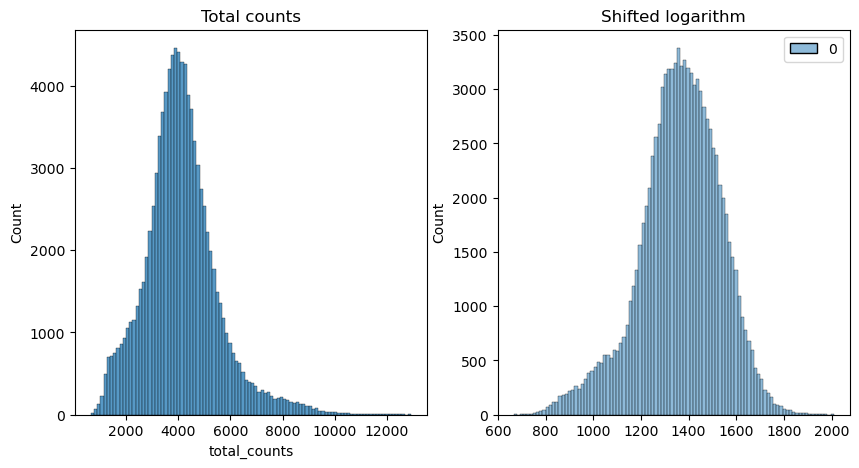

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

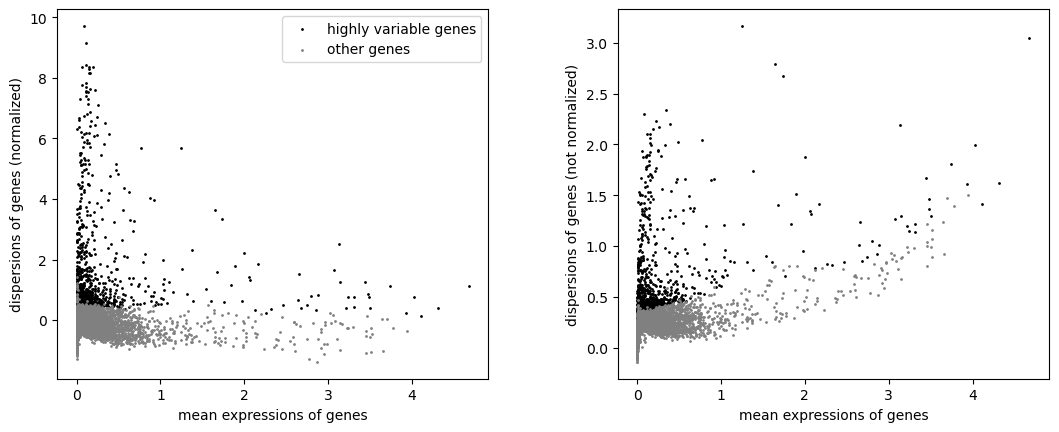

In [29]:
##### Feature Selection ##### ----------------------------------------------------------------------------------------------------
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample", layer = "log1p_norm") # automatically adds columns to adata.var 'highly_variable', 'means', 'dispersions', 'dispersions_norm'. Downstream functions like pca will automatically use only the HVGs if use_highly_variable=True is passed.
sc.pl.highly_variable_genes(adata)

# Mean expression is simply the average expression level of a gene across all cells — how highly expressed it is on average.
# Dispersion is a measure of how much a gene's expression varies across cells, normalized for its mean.

In [30]:
# Save final dataset for integration

adata.write("/rds/general/user/ztb25/home/PBMC_datasets/3/PBMC3_preprocessed.h5ad")